In [20]:
%load_ext autoreload
%autoreload 2

In [21]:
from config import config
from utils import logger
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

os.chdir(config.paths.roots.project)

torch.cuda.empty_cache()

# Check Data Module

In [22]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam0 : 579
INFO     | _get_names | Image Pair Counts : MOO07_mapping_easy cam1 : 579
INFO     | setup | Train Dataset       : 1158 samples
INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam0 : 42
INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam1 : 43
INFO     | setup | Validation Dataset  : 85 samples


In [23]:
dl = dm.train_dataloader()

In [24]:
batch = next(iter(dl))

In [25]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

rotations = batch.rotations
print(rotations.shape)

torch.Size([240, 3, 32, 32]) torch.Size([240, 3, 32, 32])
torch.Size([240, 2]) torch.Size([240, 2])
torch.Size([240])


tensor([   4.5125,    3.5097,    3.5097,   -1.5042,    4.5125,    4.5125,
           0.5014,    0.5014,    1.5042,   -0.5014,  -11.5320,   -0.5014,
          -5.5153,    4.5125,    4.5125,    4.5125,    4.5125,  -11.5320,
          -4.5125, -135.8774,    2.5070,    3.5097,    2.5070,   -9.5265,
           3.5097,    9.5265,    2.5070,   -4.5125,    3.5097,    4.5125,
           3.5097,   -0.5014,    4.5125,   -0.5014,   -3.5097,    0.5014,
          -4.5125,    3.5097,   10.5292,    5.5153,    3.5097,    6.5181,
           1.5042,   -0.5014,   17.5487,    0.5014,   -1.5042,    4.5125])


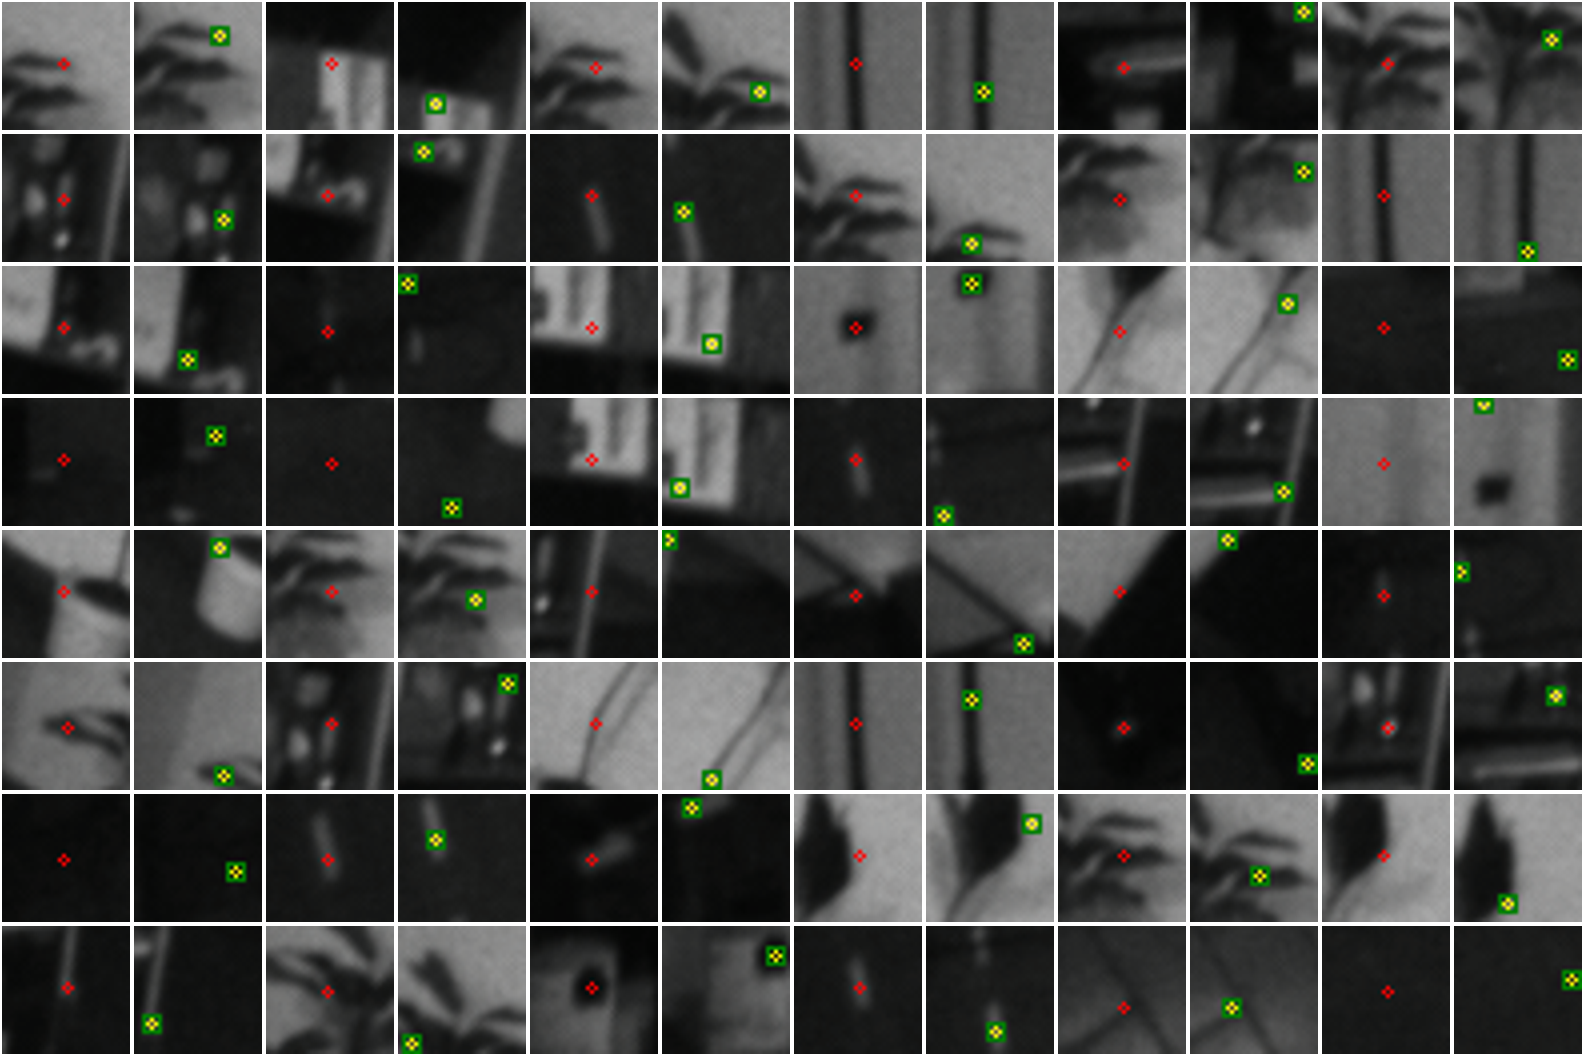

In [26]:
from utils import show_batch

count = 24 * 2

print(batch.rotations[:count] * (180 / np.pi))

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    limit_count=count, 
    n_columns=6,
)

In [27]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)


In [28]:
dm.teardown()

# Check Model

In [29]:
from src import Light
light = Light()

In [30]:
from utils import count_params
count_params(light.model)

416388

In [31]:
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

target_coords, target_rotation, target_confidence = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
print(f'target_rotation shape : {target_rotation.shape}')
print(f'target_confidence shape : {target_confidence.shape}')

reference_patches shape : torch.Size([240, 3, 32, 32])
target_patches shape : torch.Size([240, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([240, 2])
target_coords shape : torch.Size([240, 2])
target_rotation shape : torch.Size([240, 1])
target_confidence shape : torch.Size([240, 1])
